# CatBoost rain forecasting: due anni e walk-forward validation

Prevediamo `is_rain`, cioè pioggia ERA5 strettamente maggiore di 0 mm nell'ora successiva. Marzo e aprile 2026 costituiscono il test finale e non entrano mai in Optuna; tutti i dati successivi sono esclusi.

I due obiettivi restano separati:

1. **decisionale**: Optuna massimizza F1 out-of-fold; sul test riportiamo F1, precision e recall;
2. **probabilistico**: Optuna minimizza Brier out-of-fold; sul test riportiamo Brier e Brier skill rispetto alla climatologia mensile storica.

La calibrazione Venn–Abers è deliberatamente fuori dallo scope di questo notebook.

In [1]:
from dataclasses import asdict
import json
from pathlib import Path

import catboost
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.samplers import TPESampler
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'gnss_weather').exists():
    ROOT = ROOT.parent

from gnss_weather.forecasting import (
    best_f1_threshold,
    binary_metrics,
    brier_score,
    reliability_table,
    walk_forward_splits,
)

DATASET_PATH = ROOT / 'data/derived/ml/MATE00ITA_rain_hourly_2024-07-01_2026-08-20.csv'
DATASET_REPORT = DATASET_PATH.with_suffix('.json')
MODEL_DIR = ROOT / 'data/models'
OUTPUT_DIR = ROOT / 'data/derived/ml'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEST_START = pd.Timestamp('2026-03-01', tz='UTC')
TEST_END_EXCLUSIVE = pd.Timestamp('2026-05-01', tz='UTC')
N_WALK_FORWARD_SPLITS = 6
VALIDATION_DAYS = 60
FORECAST_GAP_HOURS = 1
N_DECISION_TRIALS = 20
N_PROBABILITY_TRIALS = 20
optuna.logging.set_verbosity(optuna.logging.WARNING)

{'catboost': catboost.__version__, 'optuna': optuna.__version__}

{'catboost': '1.2.10', 'optuna': '4.9.0'}

## Test finale e fold walk-forward

Il test contiene marzo e aprile 2026, due mesi con 301 ore piovose complete. Sul periodo precedente costruiamo sei validation window consecutive da 60 giorni. Il training è sempre anteriore alla validation e cresce a ogni fold. Un gap di un'ora evita che l'orizzonte del target tocchi il confine della validation. I dati da maggio 2026 in avanti non partecipano a questo esperimento.

In [2]:
dataset_metadata = json.loads(DATASET_REPORT.read_text(encoding='utf-8'))
feature_columns = dataset_metadata['feature_columns']
frame = pd.read_csv(
    DATASET_PATH,
    parse_dates=['epoch_utc', 'target_window_end_utc'],
).set_index('epoch_utc').sort_index()

assert frame.index.is_monotonic_increasing
assert not frame[feature_columns + ['is_rain']].isna().any().any()
assert dataset_metadata['rain_threshold_mm_strictly_greater_than'] == 0.0

development = frame.loc[frame.index < TEST_START].copy()
test = frame.loc[(frame.index >= TEST_START) & (frame.index < TEST_END_EXCLUSIVE)].copy()
excluded_after_test = frame.loc[frame.index >= TEST_END_EXCLUSIVE].copy()
assert not development.empty and not test.empty
assert development.index.max() < test.index.min()
folds = walk_forward_splits(
    development,
    n_splits=N_WALK_FORWARD_SPLITS,
    validation_days=VALIDATION_DAYS,
    gap_hours=FORECAST_GAP_HOURS,
)

pd.DataFrame({
    'start': [development.index.min(), test.index.min()],
    'end': [development.index.max(), test.index.max()],
    'rows': [len(development), len(test)],
    'rain_hours': [int(development.is_rain.sum()), int(test.is_rain.sum())],
    'rain_fraction': [development.is_rain.mean(), test.is_rain.mean()],
}, index=['development', 'test'])

,start,end,rows,rain_hours,rain_fraction
development,2024-07-01 03:00:00+00:00,2026-02-27 23:00:00+00:00,11466,1478,0.128903
test,2026-03-01 03:00:00+00:00,2026-04-30 23:00:00+00:00,1407,301,0.213930


In [3]:
fold_summary = pd.DataFrame([
    {
        'fold': number,
        'train_start': fold['train'].index.min(),
        'train_end': fold['train'].index.max(),
        'train_rows': len(fold['train']),
        'train_rain': int(fold['train'].is_rain.sum()),
        'validation_start': fold['validation'].index.min(),
        'validation_end': fold['validation'].index.max(),
        'validation_rows': len(fold['validation']),
        'validation_rain': int(fold['validation'].is_rain.sum()),
    }
    for number, fold in enumerate(folds, start=1)
])
fold_summary

,fold,train_start,train_end,train_rows,train_rain,validation_start,validation_end,validation_rows,validation_rain
0,1,2024-07-01 03:00:00+00:00,2025-03-04 22:00:00+00:00,4304,561,2025-03-05 00:00:00+00:00,2025-05-03 23:00:00+00:00,1203,233
1,2,2024-07-01 03:00:00+00:00,2025-05-03 22:00:00+00:00,5507,794,2025-05-04 00:00:00+00:00,2025-07-02 23:00:00+00:00,1257,83
2,3,2024-07-01 03:00:00+00:00,2025-07-02 22:00:00+00:00,6764,877,2025-07-03 00:00:00+00:00,2025-08-31 23:00:00+00:00,1311,61
3,4,2024-07-01 03:00:00+00:00,2025-08-31 22:00:00+00:00,8075,938,2025-09-01 00:00:00+00:00,2025-10-30 23:00:00+00:00,1257,153
4,5,2024-07-01 03:00:00+00:00,2025-10-30 22:00:00+00:00,9332,1091,2025-10-31 00:00:00+00:00,2025-12-10 23:00:00+00:00,852,134
5,6,2024-07-01 03:00:00+00:00,2025-12-10 23:00:00+00:00,10185,1225,2026-01-01 03:00:00+00:00,2026-02-27 23:00:00+00:00,1281,253


## Spazio di ricerca comune

I due studi esplorano lo stesso spazio ma mantengono sampler, trial e funzioni obiettivo indipendenti. Anche il numero di alberi è un iperparametro Optuna; non facciamo early stopping sul singolo fold, che introdurrebbe una seconda regola di selezione dipendente dalla sua validation.

In [4]:
BASE_PARAMETERS = dict(
    loss_function='Logloss',
    random_seed=RANDOM_SEED,
    allow_writing_files=False,
    thread_count=-1,
    bootstrap_type='Bayesian',
    verbose=False,
)

def suggest_hyperparameters(trial):
    return {
        'iterations': trial.suggest_int('iterations', 200, 800, step=100),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 30.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 3.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        'rsm': trial.suggest_float('rsm', 0.65, 1.0),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128]),
    }

def fit_model(train, parameters):
    model = CatBoostClassifier(**BASE_PARAMETERS, **parameters)
    model.fit(train[feature_columns], train['is_rain'].astype(int))
    return model

def walk_forward_predictions(parameters):
    predictions = []
    for fold_number, fold in enumerate(folds, start=1):
        model = fit_model(fold['train'], parameters)
        probability = model.predict_proba(fold['validation'][feature_columns])[:, 1]
        predictions.append(pd.DataFrame({
            'is_rain': fold['validation']['is_rain'].to_numpy(dtype=int),
            'score': probability,
            'fold': fold_number,
        }, index=fold['validation'].index))
    return pd.concat(predictions).sort_index()

## 1. Modello decisionale: Optuna su F1 walk-forward

Ogni trial addestra sei modelli, concatena tutte le predizioni out-of-fold e sceglie una sola soglia che massimizza F1 sull'insieme walk-forward. Non usiamo class weights: CatBoost vede la prevalenza naturale dell'evento e la soglia decisionale viene gestita esplicitamente. Precision, recall e F1 finali vengono calcolati una sola volta sul test.

In [5]:
def decision_objective(trial):
    oof = walk_forward_predictions(suggest_hyperparameters(trial))
    metrics = best_f1_threshold(oof['is_rain'], oof['score'])
    trial.set_user_attr('threshold', metrics.threshold)
    trial.set_user_attr('precision', metrics.precision)
    trial.set_user_attr('recall', metrics.recall)
    return metrics.f1

decision_study = optuna.create_study(
    study_name='catboost_decision_walk_forward_f1',
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_SEED),
)
decision_study.optimize(decision_objective, n_trials=N_DECISION_TRIALS, gc_after_trial=True)
decision_trials = decision_study.trials_dataframe()
decision_trials_path = OUTPUT_DIR / 'MATE00ITA_catboost_decision_2y_walkforward_mar_apr_optuna_trials.csv'
decision_trials.to_csv(decision_trials_path, index=False)
pd.Series({'best_oof_f1': decision_study.best_value, **decision_study.best_params})

best_oof_f1              0.543860
iterations             600.000000
depth                    4.000000
learning_rate            0.017424
l2_leaf_reg             19.924621
random_strength          2.278346
bagging_temperature      2.425192
rsm                      0.756615
border_count            64.000000
dtype: float64

In [6]:
decision_oof = walk_forward_predictions(decision_study.best_params)
selected_threshold = best_f1_threshold(decision_oof['is_rain'], decision_oof['score'])
decision_model = fit_model(development, decision_study.best_params)
decision_model_path = MODEL_DIR / 'rain_catboost_decision_2y_walkforward_mar_apr_test.cbm'
decision_model.save_model(decision_model_path)
test_decision_score = decision_model.predict_proba(test[feature_columns])[:, 1]
test_binary = binary_metrics(test['is_rain'], test_decision_score, selected_threshold.threshold)

decision_fold_metrics = pd.DataFrame([
    {
        'fold': fold_number,
        **asdict(binary_metrics(part['is_rain'], part['score'], selected_threshold.threshold)),
    }
    for fold_number, part in decision_oof.groupby('fold')
])
display(decision_fold_metrics[['fold', 'precision', 'recall', 'f1']])
pd.DataFrame(
    [asdict(selected_threshold), asdict(test_binary)],
    index=['walk_forward_oof', 'test_mar_apr_2026'],
)

,fold,precision,recall,f1
0,1,0.543750,0.746781,0.629295
1,2,0.656716,0.530120,0.586667
2,3,0.460000,0.377049,0.414414
3,4,0.423729,0.326797,0.369004
4,5,0.462094,0.955224,0.622871
5,6,0.378531,0.794466,0.512755


,threshold,true_positive,false_positive,false_negative,true_negative,precision,recall,f1
walk_forward_oof,0.211633,620,743,297,5501,0.454879,0.676118,0.543860
test_mar_apr_2026,0.211633,229,156,72,950,0.594805,0.760797,0.667638


## 2. Modello probabilistico: Optuna su Brier walk-forward

Il secondo studio usa le classi nella loro frequenza naturale e minimizza direttamente il Brier score sulle predizioni out-of-fold. La baseline principale è una climatologia mensile: per ogni ora del test assegna la frequenza di pioggia di quel mese, calcolata esclusivamente sul development set.

In [7]:
def probability_objective(trial):
    oof = walk_forward_predictions(suggest_hyperparameters(trial))
    return brier_score(oof['is_rain'], oof['score'])

probability_study = optuna.create_study(
    study_name='catboost_probability_walk_forward_brier',
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED),
)
probability_study.optimize(probability_objective, n_trials=N_PROBABILITY_TRIALS, gc_after_trial=True)
probability_trials = probability_study.trials_dataframe()
probability_trials_path = OUTPUT_DIR / 'MATE00ITA_catboost_probability_2y_walkforward_mar_apr_optuna_trials.csv'
probability_trials.to_csv(probability_trials_path, index=False)
pd.Series({'best_oof_brier': probability_study.best_value, **probability_study.best_params})

best_oof_brier           0.082305
iterations             600.000000
depth                    4.000000
learning_rate            0.021794
l2_leaf_reg             23.314253
random_strength          2.610080
bagging_temperature      2.995957
rsm                      0.825816
border_count            64.000000
dtype: float64

In [8]:
probability_oof = walk_forward_predictions(probability_study.best_params)
probability_model = fit_model(development, probability_study.best_params)
probability_model_path = MODEL_DIR / 'rain_catboost_probability_2y_walkforward_mar_apr_raw.cbm'
probability_model.save_model(probability_model_path)
test_probability = probability_model.predict_proba(test[feature_columns])[:, 1]
test_brier = brier_score(test['is_rain'], test_probability)

global_climatology = float(development['is_rain'].mean())
global_climatology_probability = np.full(len(test), global_climatology)
global_climatology_brier = brier_score(test['is_rain'], global_climatology_probability)

monthly_climatology = development.groupby(development.index.month)['is_rain'].mean()
monthly_climatology_probability = np.asarray(
    [monthly_climatology.loc[month] for month in test.index.month], dtype=float
)
monthly_climatology_brier = brier_score(test['is_rain'], monthly_climatology_probability)
brier_skill_monthly = 1.0 - test_brier / monthly_climatology_brier

probability_fold_metrics = pd.DataFrame([
    {
        'fold': fold_number,
        'brier': brier_score(part['is_rain'], part['score']),
        'rain_fraction': part['is_rain'].mean(),
    }
    for fold_number, part in probability_oof.groupby('fold')
])
display(probability_fold_metrics)
pd.Series({
    'walk_forward_oof_brier': brier_score(probability_oof['is_rain'], probability_oof['score']),
    'test_brier_catboost': test_brier,
    'test_brier_monthly_climatology': monthly_climatology_brier,
    'test_brier_global_climatology': global_climatology_brier,
    'test_brier_skill_vs_monthly_climatology': brier_skill_monthly,
})

,fold,brier,rain_fraction
0,1,0.114826,0.193682
1,2,0.043736,0.066030
2,3,0.036968,0.046529
3,4,0.098752,0.121718
4,5,0.083758,0.157277
5,6,0.118902,0.197502


walk_forward_oof_brier                     0.082305
test_brier_catboost                        0.101153
test_brier_monthly_climatology             0.167288
test_brier_global_climatology              0.175394
test_brier_skill_vs_monthly_climatology    0.395337
dtype: float64

## Reliability diagram raw

Il diagramma usa bin a uguale numerosità e mostra le probabilità CatBoost non calibrate. Le barre sono intervalli normali approssimativi al 95% sulla frequenza osservata: servono come diagnostica, non come garanzia conformal.

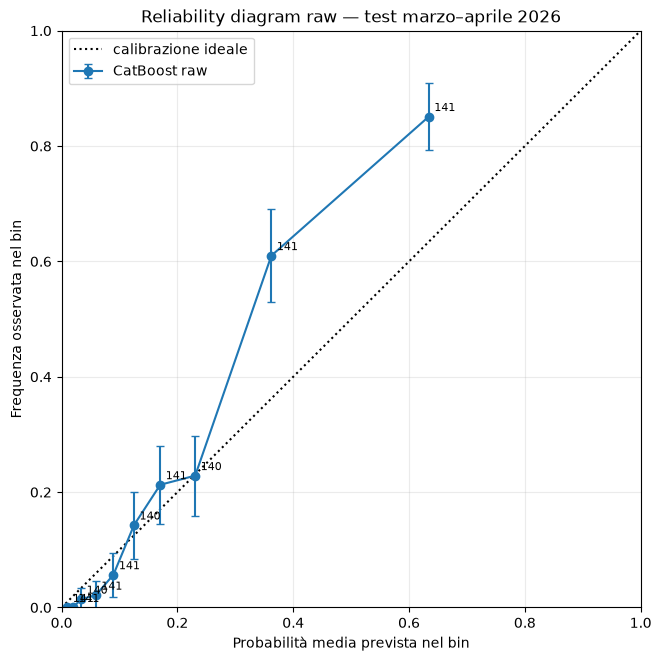

,predicted_probability,observed_frequency,count,standard_error
0,0.009733,0.000000,141,0.000000
1,0.019368,0.000000,141,0.000000
2,0.033664,0.014286,140,0.010029
3,0.059050,0.021277,141,0.012153
4,0.089418,0.056738,141,0.019482
5,0.125040,0.142857,140,0.029574
6,0.170328,0.212766,141,0.034466
7,0.230701,0.228571,140,0.035489
8,0.362247,0.609929,141,0.041077
9,0.634134,0.851064,141,0.029983


In [9]:
test_reliability = reliability_table(test['is_rain'], test_probability, bins=10)
test_reliability['standard_error'] = np.sqrt(
    test_reliability['observed_frequency']
    * (1.0 - test_reliability['observed_frequency'])
    / test_reliability['count']
)
fig, axis = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
axis.plot([0, 1], [0, 1], color='black', linestyle=':', label='calibrazione ideale')
axis.errorbar(
    test_reliability['predicted_probability'],
    test_reliability['observed_frequency'],
    yerr=1.96 * test_reliability['standard_error'],
    marker='o', capsize=3, color='tab:blue', label='CatBoost raw',
)
for row in test_reliability.itertuples():
    axis.annotate(str(row.count), (row.predicted_probability, row.observed_frequency), xytext=(4, 4), textcoords='offset points', fontsize=8)
axis.set(
    xlim=(0, 1), ylim=(0, 1),
    xlabel='Probabilità media prevista nel bin',
    ylabel='Frequenza osservata nel bin',
    title='Reliability diagram raw — test marzo–aprile 2026',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()
test_reliability

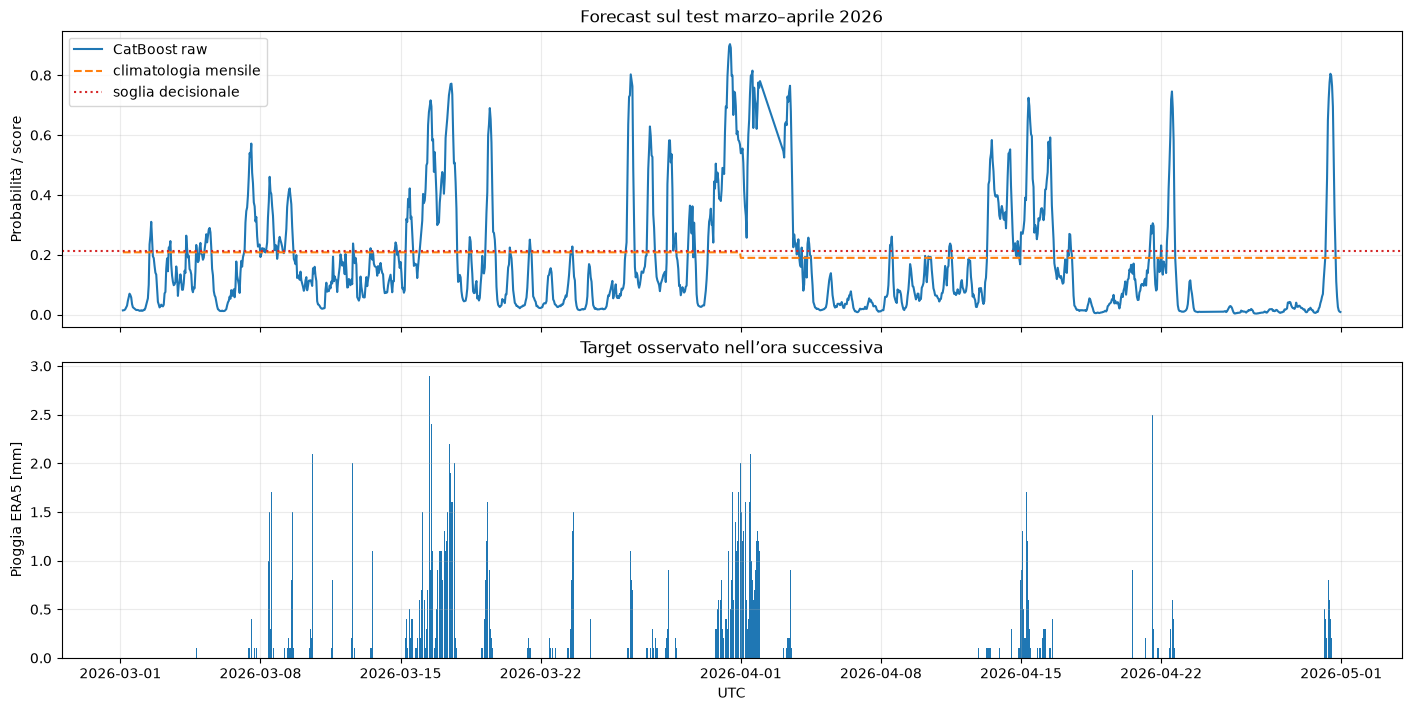

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)
axes[0].plot(test.index, test_probability, label='CatBoost raw', color='tab:blue')
axes[0].plot(test.index, monthly_climatology_probability, label='climatologia mensile', color='tab:orange', linestyle='--')
axes[0].axhline(selected_threshold.threshold, label='soglia decisionale', color='tab:red', linestyle=':')
axes[0].set(ylabel='Probabilità / score', title='Forecast sul test marzo–aprile 2026')
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].bar(test.index, test['rain_next_hour_mm'], width=0.035, color='tab:blue')
axes[1].set(xlabel='UTC', ylabel='Pioggia ERA5 [mm]', title='Target osservato nell’ora successiva')
axes[1].grid(alpha=0.25)
plt.show()

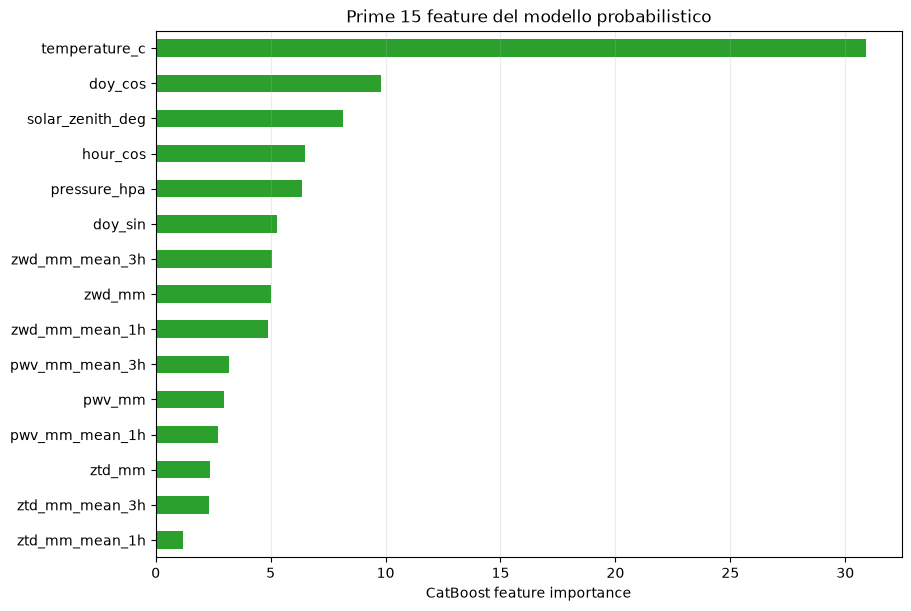

,importance
temperature_c,30.908134
doy_cos,9.812430
solar_zenith_deg,8.133724
hour_cos,6.508574
pressure_hpa,6.353269
doy_sin,5.256466
zwd_mm_mean_3h,5.066675
zwd_mm,5.010659
zwd_mm_mean_1h,4.888370
pwv_mm_mean_3h,3.205656


In [11]:
importance = pd.Series(
    probability_model.get_feature_importance(),
    index=feature_columns,
).sort_values(ascending=False)
fig, axis = plt.subplots(figsize=(9, 6), constrained_layout=True)
importance.head(15).sort_values().plot.barh(ax=axis, color='tab:green')
axis.set(xlabel='CatBoost feature importance', title='Prime 15 feature del modello probabilistico')
axis.grid(axis='x', alpha=0.25)
plt.show()
importance.head(15).to_frame('importance')

## Salvataggio degli artefatti

Salviamo modelli finali, predizioni del test, metriche, risultati per fold e tutti i trial Optuna. I file hanno nomi specifici `2y_walkforward`, così gli esperimenti precedenti non vengono confusi con questo.

In [12]:
test_predictions = pd.DataFrame({
    'epoch_utc': test.index,
    'is_rain': test['is_rain'].to_numpy(dtype=int),
    'rain_next_hour_mm': test['rain_next_hour_mm'].to_numpy(),
    'decision_score': test_decision_score,
    'decision_prediction': (test_decision_score >= selected_threshold.threshold).astype(int),
    'probability_raw': test_probability,
    'monthly_climatology_probability': monthly_climatology_probability,
})
test_predictions_path = OUTPUT_DIR / 'MATE00ITA_catboost_2y_walkforward_mar_apr_test_predictions.csv'
test_predictions.to_csv(test_predictions_path, index=False)
test_reliability_path = OUTPUT_DIR / 'MATE00ITA_catboost_2y_walkforward_mar_apr_reliability.csv'
test_reliability.to_csv(test_reliability_path, index=False)

decision_fold_path = OUTPUT_DIR / 'MATE00ITA_catboost_decision_2y_walkforward_mar_apr_folds.csv'
probability_fold_path = OUTPUT_DIR / 'MATE00ITA_catboost_probability_2y_walkforward_mar_apr_folds.csv'
decision_fold_metrics.to_csv(decision_fold_path, index=False)
probability_fold_metrics.to_csv(probability_fold_path, index=False)

def period_summary(part):
    return {
        'start': part.index.min().isoformat(),
        'end': part.index.max().isoformat(),
        'rows': len(part),
        'rain_hours': int(part['is_rain'].sum()),
        'rain_fraction': float(part['is_rain'].mean()),
    }

metrics = {
    'dataset': str(DATASET_PATH.relative_to(ROOT)),
    'catboost_version': catboost.__version__,
    'optuna_version': optuna.__version__,
    'random_seed': RANDOM_SEED,
    'target': dataset_metadata['rain_target'],
    'feature_columns': feature_columns,
    'class_weighting': 'none for both models',
    'development': period_summary(development),
    'test': period_summary(test),
    'test_policy': 'fixed holdout 2026-03-01 through 2026-04-30; later data excluded',
    'walk_forward': {
        'splits': N_WALK_FORWARD_SPLITS,
        'validation_days': VALIDATION_DAYS,
        'forecast_gap_hours': FORECAST_GAP_HOURS,
        'folds': fold_summary.astype(object).where(pd.notna(fold_summary), None).to_dict(orient='records'),
    },
    'decision_model': {
        'objective': 'maximize pooled walk-forward out-of-fold F1',
        'optuna_trials': N_DECISION_TRIALS,
        'best_hyperparameters': decision_study.best_params,
        'walk_forward_oof': asdict(selected_threshold),
        'test': asdict(test_binary),
        'model_path': str(decision_model_path.relative_to(ROOT)),
        'trials_path': str(decision_trials_path.relative_to(ROOT)),
        'fold_metrics_path': str(decision_fold_path.relative_to(ROOT)),
    },
    'probability_model_raw': {
        'objective': 'minimize pooled walk-forward out-of-fold Brier score',
        'optuna_trials': N_PROBABILITY_TRIALS,
        'best_hyperparameters': probability_study.best_params,
        'walk_forward_oof_brier': brier_score(probability_oof['is_rain'], probability_oof['score']),
        'test_brier': test_brier,
        'test_monthly_climatology_brier': monthly_climatology_brier,
        'test_global_climatology_brier': global_climatology_brier,
        'test_brier_skill_vs_monthly_climatology': brier_skill_monthly,
        'monthly_climatology': {str(month): float(value) for month, value in monthly_climatology.items()},
        'model_path': str(probability_model_path.relative_to(ROOT)),
        'trials_path': str(probability_trials_path.relative_to(ROOT)),
        'fold_metrics_path': str(probability_fold_path.relative_to(ROOT)),
    },
    'test_predictions_path': str(test_predictions_path.relative_to(ROOT)),
    'test_reliability_path': str(test_reliability_path.relative_to(ROOT)),
}
metrics_path = OUTPUT_DIR / 'MATE00ITA_catboost_2y_walkforward_mar_apr_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2, default=str) + '\n', encoding='utf-8')
metrics_path, test_predictions_path

(WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_catboost_2y_walkforward_mar_apr_metrics.json'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_catboost_2y_walkforward_mar_apr_test_predictions.csv'))

## Limiti

- I giorni senza TRO non vengono imputati, quindi il numero di righe è inferiore alle ore di calendario.
- La climatologia mensile usa solo il passato ed è più corretta della media annuale, ma due anni restano pochi per stimarla.
- Il target è pioggia ERA5 sulla cella, non una misura da pluviometro locale.
- I fold walk-forward riducono il selection bias stagionale, ma una sola stazione non dimostra generalizzazione geografica.